In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import Markdown, display

from neuro.config import NeuroConfig, NeuroTrainConfig
from neuro.faster_rcnn import NeuroFasterRCNN
from neuro.prepare_dataset import PCBDataset
from neuro.preprocess_dataset import test_preprocess
from symbolic.config import SymbolicTrainConfig
from symbolic.export import extract_dataset_from_teacher, summarize_symbolic_export
from symbolic.train import (
    train_symbolic_tree,
    evaluate_heldout,
    load_symbolic_tree,
    prune_symbolic_tree,
)
from util.artifacts import next_run_artifacts
from util.config import load_yaml
from util.device import select_device

train_config = load_yaml(Path("neuro_train.yaml"), NeuroTrainConfig)
neuro_config = load_yaml(Path("neuro.yaml"), NeuroConfig)
symbolic_train_config = load_yaml(Path("symbolic_train.yaml"), SymbolicTrainConfig)

device = select_device(train_config["device"])
class_names = tuple(train_config["dataset"]["class_names"])

checkpoint_path = Path("checkpoints") / "neuro" / "run1.pt"
checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=True)

model = NeuroFasterRCNN(
    neuro_config=neuro_config,
    train_config=train_config,
).to(device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

symbolic_dir = Path("checkpoints") / "symbolic"


# Checkpoint selection: set to a filename under checkpoints/symbolic (e.g., "run2.pt") to skip training and evaluate that checkpoint.
# Set to "" to train from scratch.
def train_or_use(checkpoint_name: str = "") -> str | None:
    return checkpoint_name if checkpoint_name.strip() else None


use_checkpoint = train_or_use()

if not use_checkpoint:
    next_run = next_run_artifacts(symbolic_dir)
    symbolic_checkpoint_path = next_run.checkpoint_path
    symbolic_summary_path = next_run.metrics_path
else:
    symbolic_checkpoint_path = symbolic_dir / use_checkpoint
    symbolic_summary_path = symbolic_dir / use_checkpoint.replace(
        ".pt", "_metrics.json"
    )

teacher_trainval_path = symbolic_dir / "teacher_trainval_new.pt"
teacher_test_path = symbolic_dir / "teacher_test_new.pt"

checkpoint_path, class_names

(PosixPath('checkpoints/neuro/run1.pt'),
 ('open', 'short', 'mouse_bite', 'spur', 'pinhole', 'spurious_copper'))

In [2]:
trainval_dataset = PCBDataset(train_config, "trainval.txt")
trainval_dataset.add_preprocess(test_preprocess())

test_dataset = PCBDataset(train_config, "test.txt")
test_dataset.add_preprocess(test_preprocess())

symbolic_data_config = symbolic_train_config["data"]
storage_dtype = str(symbolic_data_config["storage_dtype"])

len(trainval_dataset), len(test_dataset)

(1000, 500)

In [3]:
if (
    use_checkpoint
    and Path(teacher_trainval_path).exists()
    and Path(teacher_test_path).exists()
):
    print(
        f"Skipping feature extraction since pre-trained checkpoint {use_checkpoint} is used and feature files already exist."
    )
else:
    extract_dataset_from_teacher(
        model=model,
        dataset=trainval_dataset,
        output_path=teacher_trainval_path,
        device=train_config["device"],
        storage_dtype=storage_dtype,
    )
    extract_dataset_from_teacher(
        model=model,
        dataset=test_dataset,
        output_path=teacher_test_path,
        device=train_config["device"],
        storage_dtype=storage_dtype,
    )

teacher_trainval_path, teacher_test_path

(PosixPath('checkpoints/symbolic/teacher_trainval_new.pt'),
 PosixPath('checkpoints/symbolic/teacher_test_new.pt'))

In [4]:
trainval_manifest, trainval_overview, trainval_counts = summarize_symbolic_export(
    teacher_trainval_path,
    "trainval",
)
test_manifest, test_overview, test_counts = summarize_symbolic_export(
    teacher_test_path,
    "test",
)

display(pd.concat([trainval_overview, test_overview], ignore_index=True))
display(pd.concat([trainval_counts, test_counts], ignore_index=True))

,split,images,total_rois,background_rois,positive_rois,feature_shape,feature_cut,symbolic_target,proposal_source
0,trainval,1000,1000000,865662,134338,64x7x7,roi_align_pooled_grid,teacher_label,rpn_pre_detector_postprocess
1,test,500,500000,436460,63540,64x7x7,roi_align_pooled_grid,teacher_label,rpn_pre_detector_postprocess


,split,class_name,count
0,trainval,__background__,865662
1,trainval,open,27006
2,trainval,short,19208
3,trainval,mouse_bite,26897
4,trainval,spur,21268
5,trainval,pinhole,19246
6,trainval,spurious_copper,20713
7,test,__background__,436460
8,test,open,14024
9,test,short,9538


## RoI Align Spatial Topology

Visualize the (C, 7, 7) RoI Align pooled tensors to verify that spatial geometry is preserved in the feature grid before being flattened for SODT training.

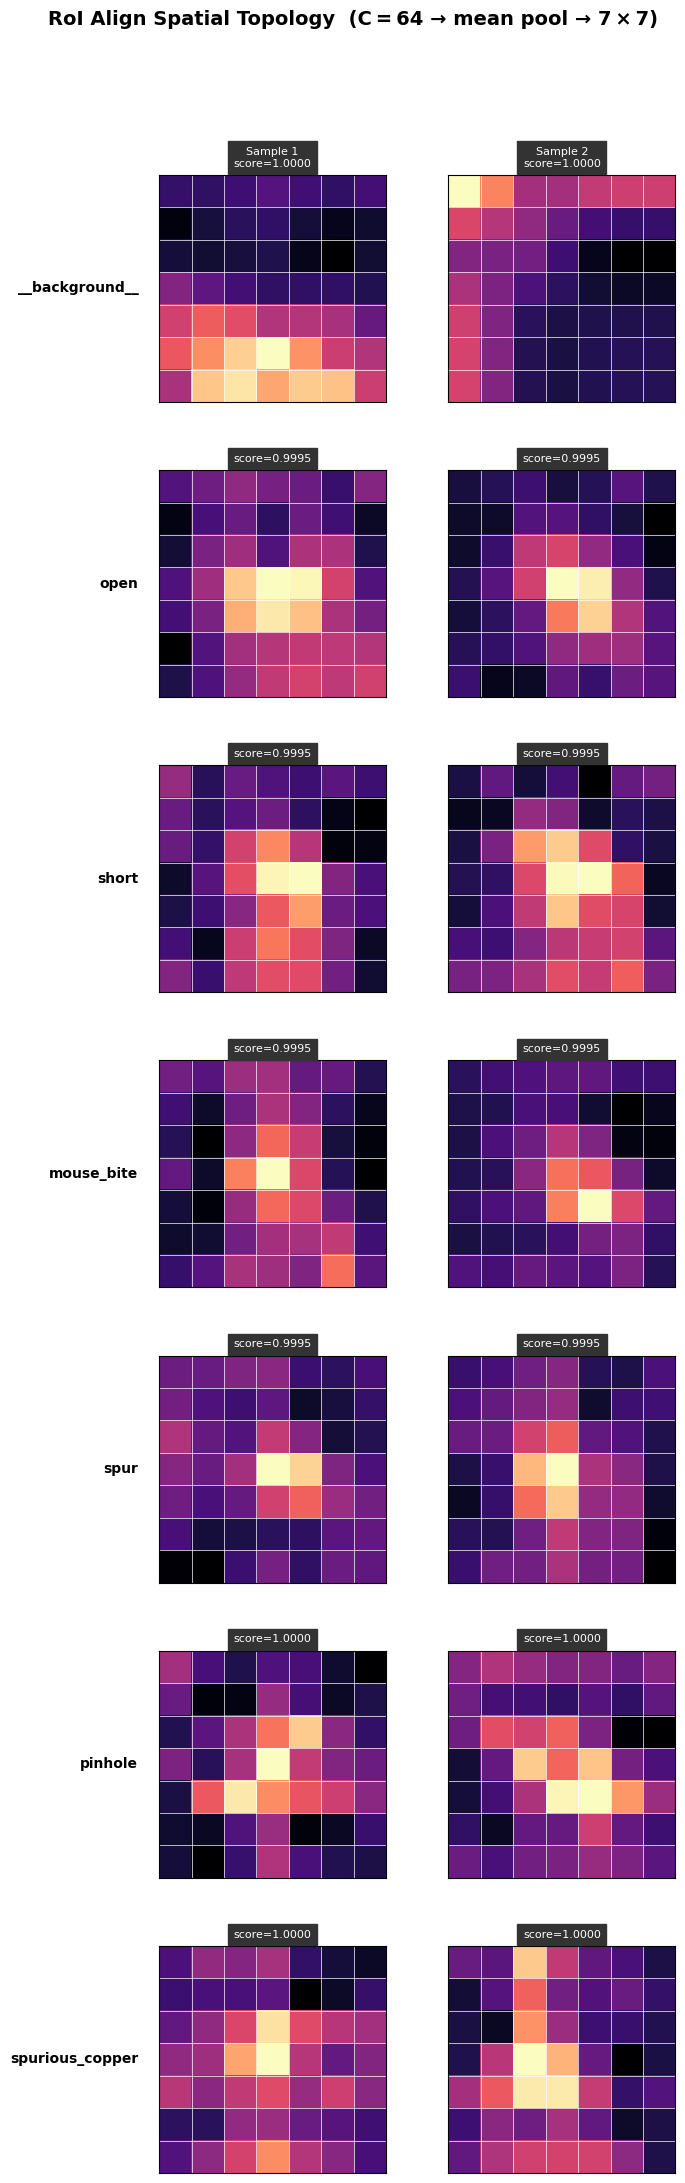

In [5]:
from symbolic.visualization import visualize_spatial_topology

fig = visualize_spatial_topology(teacher_trainval_path, num_samples=2, seed=42)
plt.show()

## Hyperparameter Selection (Validation Sweep)

Select `tree_depth` / `l1_lambda` / `sparsity_alpha` / `class_weights` on a held-out
**validation** split of `trainval` — never on `test.txt`. This matches Hada §4 step 1
("pick a tree with close to highest validation accuracy and as sparse as possible")
and Kairgeldin's (λ, α) regularization-path selection.

The grid below reuses the six configs already explored in
`checkpoints/symbolic/run1..run6`, plus one class-weighting ablation, so this sweep
is a proper re-run of that exploration on `val` instead of on `test.txt`. Each grid
point trains on the `train` image slice and is scored on the `val` image slice — both
carved from `trainval` by `split`/`val_fraction`/`split_seed` in `symbolic_train.yaml`
(`symbolic/dataset.py::_image_level_split_row_indices`). `test.txt` is untouched here.

Sweep checkpoints are written under `checkpoints/symbolic/val_sweep/` — a separate
directory from the promoted `runN.pt` checkpoints, so this exploration doesn't
consume the run-numbering sequence.

In [6]:
import copy

_DEFAULT_CLASS_WEIGHTS = {"short": 2.0, "spur": 1.5}

# Seeded from checkpoints/symbolic/run1..run6 (tree_depth, l1_lambda, sparsity_alpha),
# plus one class-weighting ablation on the strongest base config.
VAL_SWEEP_GRID = [
    {"label": "depth6_l1=0.001_a=0.9", "tree_depth": 6, "l1_lambda": 0.001, "sparsity_alpha": 0.9, "class_weights": _DEFAULT_CLASS_WEIGHTS},
    {"label": "depth5_l1=0.01_a=0.5", "tree_depth": 5, "l1_lambda": 0.01, "sparsity_alpha": 0.5, "class_weights": _DEFAULT_CLASS_WEIGHTS},
    {"label": "depth5_l1=0.0001_a=0.9", "tree_depth": 5, "l1_lambda": 0.0001, "sparsity_alpha": 0.9, "class_weights": _DEFAULT_CLASS_WEIGHTS},
    {"label": "depth5_l1=0.0001_a=0.95", "tree_depth": 5, "l1_lambda": 0.0001, "sparsity_alpha": 0.95, "class_weights": _DEFAULT_CLASS_WEIGHTS},
    {"label": "depth5_l1=0.2_a=0.5", "tree_depth": 5, "l1_lambda": 0.2, "sparsity_alpha": 0.5, "class_weights": _DEFAULT_CLASS_WEIGHTS},
    {"label": "depth5_l1=0.75_a=0.35", "tree_depth": 5, "l1_lambda": 0.75, "sparsity_alpha": 0.35, "class_weights": _DEFAULT_CLASS_WEIGHTS},
    {"label": "depth6_l1=0.001_a=0.9_no_class_weights", "tree_depth": 6, "l1_lambda": 0.001, "sparsity_alpha": 0.9, "class_weights": None},
]


def _sweep_config(base_config: SymbolicTrainConfig, grid_row: dict) -> SymbolicTrainConfig:
    """Trainval config for one grid point, trained on the `train` image slice."""
    cfg = copy.deepcopy(base_config)
    cfg["data"]["split"] = "train"
    cfg["search"]["tree_depth"] = grid_row["tree_depth"]
    cfg["search"]["l1_lambda"] = grid_row["l1_lambda"]
    cfg["search"]["sparsity_alpha"] = grid_row["sparsity_alpha"]
    cfg["search"]["class_weights"] = grid_row["class_weights"]
    return cfg


val_sweep_dir = symbolic_dir / "val_sweep"
val_sweep_dir.mkdir(parents=True, exist_ok=True)

len(VAL_SWEEP_GRID)

7

In [7]:
sweep_rows = []

for grid_row in VAL_SWEEP_GRID:
    label = grid_row["label"]
    sweep_checkpoint_path = val_sweep_dir / f"{label}.pt"

    print(f"\n=== Val sweep: {label} ===")
    sweep_config = _sweep_config(symbolic_train_config, grid_row)
    _summary, _ = train_symbolic_tree(
        export_path=teacher_trainval_path,
        output_path=sweep_checkpoint_path,
        config=sweep_config,
    )

    val_eval = evaluate_heldout(
        export_path=teacher_trainval_path,
        checkpoint_path=sweep_checkpoint_path,
        split="val",
        val_fraction=float(symbolic_train_config["data"].get("val_fraction", 0.2)),
        split_seed=int(symbolic_train_config["data"].get("split_seed", 0)),
    )
    val_metrics = val_eval["metrics"]

    sweep_rows.append(
        {
            "label": label,
            "tree_depth": grid_row["tree_depth"],
            "l1_lambda": grid_row["l1_lambda"],
            "sparsity_alpha": grid_row["sparsity_alpha"],
            "class_weights_on": grid_row["class_weights"] is not None,
            "val_mimic_accuracy": val_metrics["mimic_accuracy"],
            "val_macro_f1_vs_teacher": val_metrics.get("macro_f1_vs_teacher"),
            "active_internal_nodes": val_metrics.get("active_internal_nodes"),
            "nonzero_weights": val_metrics.get("nonzero_weights"),
        }
    )

val_sweep_results = pd.DataFrame(sweep_rows).sort_values(
    "val_mimic_accuracy", ascending=False
)
val_sweep_results


=== Val sweep: depth6_l1=0.001_a=0.9 ===
Loading symbolic training export from checkpoints/symbolic/teacher_trainval_new.pt...
Symbolic training data ready in 2m 11s.

       Selected RoI Class Distribution       
---------------------------------------------
Class Name                |   Selected RoIs
---------------------------------------------
__background__            |         214,244
open                      |          21,373
short                     |          15,229
mouse_bite                |          21,528
spur                      |          17,088
pinhole                   |          15,471
spurious_copper           |          16,433

Loaded 321366 symbolic samples with 3136 raw RoI-pooled feature dimensions.
TAO consumes the full RoI Align feature vector. Symbolic sparsity comes only from L1 regularization and the tree structure.
Training one configured SODT on the configured trainval RoI set: depth=6, lambda=0.001, alpha=0.9.
Workload check: 15 TAO iterations and up 

TAO 15/15 nodes: 100%|██████████| 63/63 [01:10<00:00,  1.12s/it, iteration_done | mimic=0.9588 nz=171292]


Loading heldout evaluation data from checkpoints/symbolic/teacher_trainval_new.pt...
Loaded 200,000 samples in 1m 03s
Evaluating on held-out set...


Spatial grounding: 100%|██████████| 200000/200000 [00:28<00:00, 7111.87it/s]



=== Val sweep: depth5_l1=0.01_a=0.5 ===
Loading symbolic training export from checkpoints/symbolic/teacher_trainval_new.pt...
Symbolic training data ready in 1s.

       Selected RoI Class Distribution       
---------------------------------------------
Class Name                |   Selected RoIs
---------------------------------------------
__background__            |         214,244
open                      |          21,373
short                     |          15,229
mouse_bite                |          21,528
spur                      |          17,088
pinhole                   |          15,471
spurious_copper           |          16,433

Loaded 321366 symbolic samples with 3136 raw RoI-pooled feature dimensions.
TAO consumes the full RoI Align feature vector. Symbolic sparsity comes only from L1 regularization and the tree structure.
Training one configured SODT on the configured trainval RoI set: depth=5, lambda=0.01, alpha=0.5.
Workload check: 15 TAO iterations and up to 465

...


=== Val sweep: depth6_l1=0.001_a=0.9_no_class_weights ===
Loading symbolic training export from checkpoints/symbolic/teacher_trainval_new.pt...
Symbolic training data ready in 1s.

       Selected RoI Class Distribution       
---------------------------------------------
Class Name                |   Selected RoIs
---------------------------------------------
__background__            |         214,244
open                      |          21,373
short                     |          15,229
mouse_bite                |          21,528
spur                      |          17,088
pinhole                   |          15,471
spurious_copper           |          16,433

Loaded 321366 symbolic samples with 3136 raw RoI-pooled feature dimensions.
TAO consumes the full RoI Align feature vector. Symbolic sparsity comes only from L1 regularization and the tree structure.
Training one configured SODT on the configured trainval RoI set: depth=6, lambda=0.001, alpha=0.9.
Workload check: 15 TAO itera

TAO 5/15 nodes: 100%|██████████| 63/63 [01:00<00:00,  1.04it/s, iteration_done | mimic=0.7270 nz=179894]


Loading heldout evaluation data from checkpoints/symbolic/teacher_trainval_new.pt...
Loaded 200,000 samples in 1s
Evaluating on held-out set...


Spatial grounding: 100%|██████████| 200000/200000 [00:27<00:00, 7265.40it/s]


,label,tree_depth,l1_lambda,sparsity_alpha,class_weights_on,val_mimic_accuracy,val_macro_f1_vs_teacher,active_internal_nodes,nonzero_weights
0,depth6_l1=0.001_a=0.9,6,0.0010,0.90,True,0.957030,0.873739,62,171292
6,depth6_l1=0.001_a=0.9_no_class_weights,6,0.0010,0.90,False,0.884075,0.228024,63,179894
1,depth5_l1=0.01_a=0.5,5,0.0100,0.50,True,0.863920,0.132428,31,97216
2,depth5_l1=0.0001_a=0.9,5,0.0001,0.90,True,0.863920,0.132428,31,97216
3,depth5_l1=0.0001_a=0.95,5,0.0001,0.95,True,0.863920,0.132428,31,97216
4,depth5_l1=0.2_a=0.5,5,0.2000,0.50,True,0.863920,0.132428,31,97216
5,depth5_l1=0.75_a=0.35,5,0.7500,0.35,True,0.863920,0.132428,31,97216


### Promote a config

Per Hada §4 step 1: pick the row with close to the highest `val_mimic_accuracy`
that is also as sparse as possible (low `active_internal_nodes` /
`nonzero_weights`) — not necessarily the single highest-accuracy row. Read
`val_sweep_results` above and set `SELECTED_SWEEP_LABEL` below to that row's
`label`. This is a manual choice — the cell below does not pick for you.

The "## Training" section further down then trains on the **full** `trainval`
dump (`split=None`) with the selected hyperparameters, and `test.txt` is
evaluated exactly once, in the "## Heldout Evaluation" section.

In [8]:
# Set this from val_sweep_results above (e.g. "depth6_l1=0.001_a=0.9").
SELECTED_SWEEP_LABEL = ""

if SELECTED_SWEEP_LABEL:
    selected_row = next(
        row for row in VAL_SWEEP_GRID if row["label"] == SELECTED_SWEEP_LABEL
    )
    symbolic_train_config["search"]["tree_depth"] = selected_row["tree_depth"]
    symbolic_train_config["search"]["l1_lambda"] = selected_row["l1_lambda"]
    symbolic_train_config["search"]["sparsity_alpha"] = selected_row["sparsity_alpha"]
    symbolic_train_config["search"]["class_weights"] = selected_row["class_weights"]
    symbolic_train_config["data"]["split"] = None  # train on the full trainval dump
    print(f"Promoted '{SELECTED_SWEEP_LABEL}' — training below will use this config.")
else:
    print(
        "SELECTED_SWEEP_LABEL is empty — the '## Training' section below will use "
        "whatever is currently in symbolic_train.yaml, unmodified by the sweep."
    )

symbolic_train_config["search"]

SELECTED_SWEEP_LABEL is empty — the '## Training' section below will use whatever is currently in symbolic_train.yaml, unmodified by the sweep.


{'tree_depth': 6,
 'iterations': 15,
 'l1_lambda': 0.001,
 'sparsity_alpha': 0.9,
 'logistic_max_iter': 200,
 'tolerance': 0.0001,
 'zero_threshold': 1e-05,
 'random_state': 112,
 'class_weights': {'short': 2.0, 'spur': 1.5}}

## Training

In [9]:
if not use_checkpoint:
    summary, training_state = train_symbolic_tree(
        export_path=teacher_trainval_path,
        output_path=symbolic_checkpoint_path,
        summary_path=symbolic_summary_path,
        config=symbolic_train_config,
    )
    summary = prune_symbolic_tree(
        **training_state,
        checkpoint_path=symbolic_checkpoint_path,
        summary_path=symbolic_summary_path,
    )
else:
    print(
        f"Skipping training/pruning. Loading pre-trained summary from {symbolic_summary_path}..."
    )
    import json

    with open(symbolic_summary_path, "r", encoding="utf-8") as f:
        summary = json.load(f)

summary

Loading symbolic training export from checkpoints/symbolic/teacher_trainval_new.pt...
Symbolic training data ready in 2m 21s.

       Selected RoI Class Distribution       
---------------------------------------------
Class Name                |   Selected RoIs
---------------------------------------------
__background__            |         268,676
open                      |          27,006
short                     |          19,208
mouse_bite                |          26,897
spur                      |          21,268
pinhole                   |          19,246
spurious_copper           |          20,713

Loaded 403014 symbolic samples with 3136 raw RoI-pooled feature dimensions.
TAO consumes the full RoI Align feature vector. Symbolic sparsity comes only from L1 regularization and the tree structure.
Training one configured SODT on the configured trainval RoI set: depth=6, lambda=0.001, alpha=0.9.
Workload check: 15 TAO iterations and up to 945 LIBLINEAR node fits.
Each TAO itera

TAO 2/15 nodes: 100%|██████████| 63/63 [00:49<00:00,  1.27it/s, iteration_done | mimic=0.6667 nz=197568]


=== Pruning Symbolic Tree ===
Tree: 403,014 RoIs, 63 internal nodes
Walking 63 internal nodes (reverse BFS)...
  Node 62 (depth 5): pruned — pure subtree (all leaves → __background__)
  Node 61 (depth 5): pruned — pure subtree (all leaves → __background__)
  Node 60 (depth 5): pruned — pure subtree (all leaves → __background__)
  Node 59 (depth 5): pruned — pure subtree (all leaves → __background__)
  Node 58 (depth 5): pruned — pure subtree (all leaves → __background__)
  Node 57 (depth 5): pruned — pure subtree (all leaves → __background__)
  Node 56 (depth 5): pruned — pure subtree (all leaves → __background__)
  Node 55 (depth 5): pruned — pure subtree (all leaves → __background__)
  Node 54 (depth 5): pruned — pure subtree (all leaves → __background__)
  Node 53 (depth 5): pruned — pure subtree (all leaves → __background__)
  Node 52 (depth 5): pruned — pure subtree (all leaves → __background__)
  Node 51 (depth 5): pruned — pure subtree (all leaves → __background__)
  Node 50 (de

{'export_path': 'checkpoints/symbolic/teacher_trainval_new.pt',
 'output_path': 'checkpoints/symbolic/run1.pt',
 'metrics': {'tree_depth': 6,
  'num_leaves': 64,
  'num_internal_nodes': 63,
  'nonzero_weights': 0,
  'mean_nonzero_per_node': 0.0,
  'active_internal_nodes': 0,
  'mean_nonzero_per_active_node': 0.0},
 'history': [{'mimic_accuracy': 0.6666666666666666,
   'nonzero_weights': 197568,
   'mean_nonzero_per_node': 3136.0,
   'active_internal_nodes': 63,
   'objective': 2058442.4126876194,
   'iteration': 1,
   'duration_seconds': 49.40949583100155},
  {'mimic_accuracy': 0.6666666666666666,
   'nonzero_weights': 197568,
   'mean_nonzero_per_node': 3136.0,
   'active_internal_nodes': 63,
   'objective': 2058442.4126876194,
   'iteration': 2,
   'duration_seconds': 49.589126851999026},
  {'iteration': 3,
   'nonzero_weights': 0,
   'active_internal_nodes': 0,
   'postprocess_pruned_nodes': 63}],
 'class_names': ('__background__',
  'open',
  'short',
  'mouse_bite',
  'spur',
  'p

## Heldout Evaluation

In [ ]:
heldout_eval = evaluate_heldout(
    export_path=teacher_test_path,
    checkpoint_path=symbolic_checkpoint_path,
)
hm = heldout_eval["metrics"]
print(
    f"Mimic accuracy: {hm['mimic_accuracy']:.4f}\n"
    f"Macro F1: {hm.get('macro_f1_vs_teacher', 0.0):.4f}\n"
    f"Necessity flip rate: {hm.get('necessity_prediction_flip_rate', 0.0):.4f}\n"
    f"Sufficiency preservation: {hm.get('sufficiency_prediction_preservation', 0.0):.4f}\n"
    f"Deletion AUC: {hm.get('deletion_auc', 0.0):.4f}\n"
    f"Insertion AUC: {hm.get('insertion_auc', 0.0):.4f}"
)
print("Per-class agreement:")
for cls, val in hm.get("per_class_agreement_vs_teacher", {}).items():
    print(f"  {cls}: {val:.4f}")
print(
    f"Spatial — overlap: {hm.get('box_grounded_roi_overlap', 0.0):.4f}, pointing: {hm.get('pointing_score', 0.0):.4f}"
)

Loading heldout evaluation data from checkpoints/symbolic/teacher_test_new.pt...


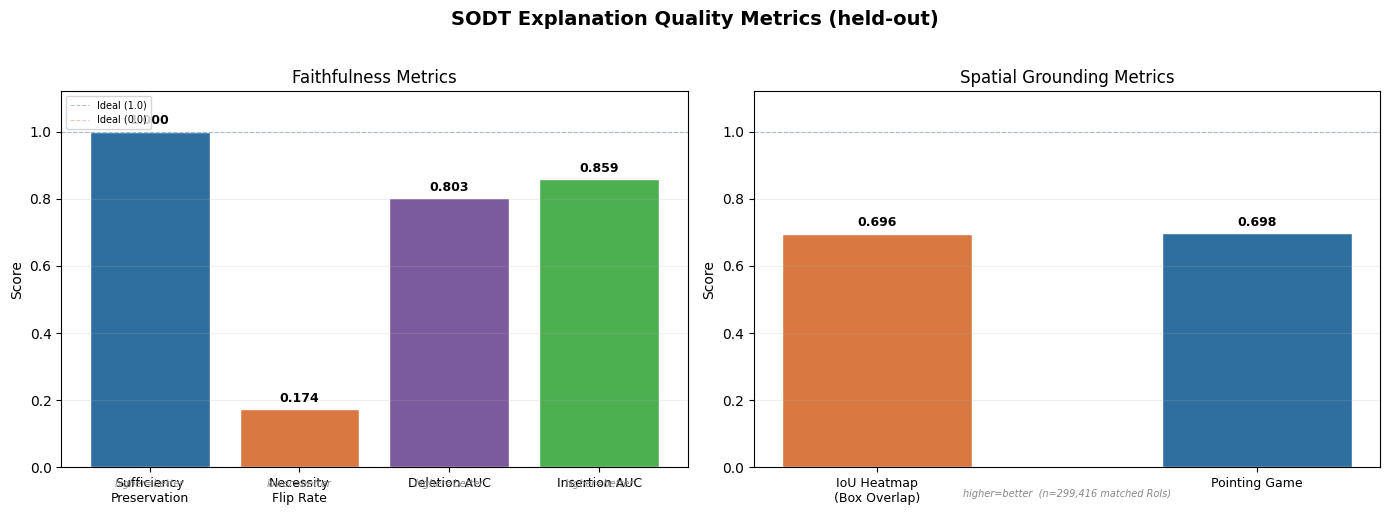

In [ ]:
hm = heldout_eval["metrics"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    "SODT Explanation Quality Metrics (held-out)",
    fontsize=14,
    fontweight="bold",
    y=1.02,
)

# --- Panel 1: Faithfulness metrics ---
ax = axes[0]
faith_labels = [
    "Sufficiency\nPreservation",
    "Necessity\nFlip Rate",
    "Deletion AUC",
    "Insertion AUC",
]
faith_values = [
    hm.get("sufficiency_prediction_preservation", 0.0),
    hm.get("necessity_prediction_flip_rate", 0.0),
    hm.get("deletion_auc", 0.0),
    hm.get("insertion_auc", 0.0),
]
faith_colors = ["#2F6F9F", "#D97941", "#7C5A9E", "#4CAF50"]
bars = ax.bar(
    range(len(faith_labels)), faith_values, color=faith_colors, edgecolor="white"
)
ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=9, fontweight="bold")
ax.set_xticks(range(len(faith_labels)))
ax.set_xticklabels(faith_labels, fontsize=9)
ax.set_ylim(0, 1.12)
ax.set_ylabel("Score")
ax.set_title("Faithfulness Metrics")
ax.axhline(y=1.0, color="#2F6F9F", ls="--", lw=0.8, alpha=0.4, label="Ideal (1.0)")
ax.axhline(y=0.0, color="#D97941", ls="--", lw=0.8, alpha=0.4, label="Ideal (0.0)")
ax.legend(fontsize=7, loc="upper left")
ax.grid(axis="y", alpha=0.2)
for i, v in enumerate(faith_values):
    ax.text(
        i,
        -0.06,
        "lower=better" if i == 1 else "higher=better",
        ha="center",
        fontsize=7,
        color="#888888",
        style="italic",
    )

# --- Panel 2: Spatial grounding metrics ---
ax = axes[1]
spatial_labels = ["IoU Heatmap\n(Box Overlap)", "Pointing Game"]
spatial_values = [
    hm.get("box_grounded_roi_overlap", 0.0),
    hm.get("pointing_score", 0.0),
]
spatial_colors = ["#D97941", "#2F6F9F"]
bars = ax.bar(
    range(len(spatial_labels)),
    spatial_values,
    color=spatial_colors,
    edgecolor="white",
    width=0.5,
)
ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=9, fontweight="bold")
ax.set_xticks(range(len(spatial_labels)))
ax.set_xticklabels(spatial_labels, fontsize=9)
ax.set_ylim(0, 1.12)
ax.set_ylabel("Score")
ax.set_title("Spatial Grounding Metrics")
ax.axhline(y=1.0, color="#2F6F9F", ls="--", lw=0.8, alpha=0.4)
ax.grid(axis="y", alpha=0.2)
n_eval = hm.get("evaluated_roi_count", 0)
ax.text(
    0.5,
    -0.08,
    f"higher=better  (n={n_eval:,} matched RoIs)",
    ha="center",
    fontsize=7,
    color="#888888",
    style="italic",
    transform=ax.transAxes,
)

plt.tight_layout()
plt.show()

## Student Metrics & Explanation Quality

Detection mimic accuracy, weight sparsity, faithfulness metrics, and per-class agreement.

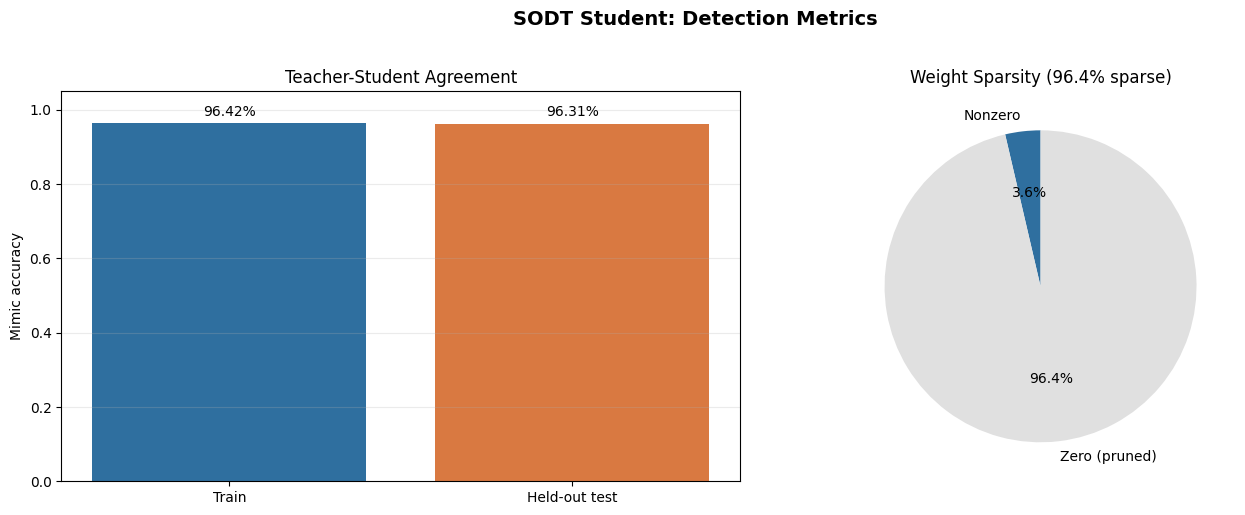

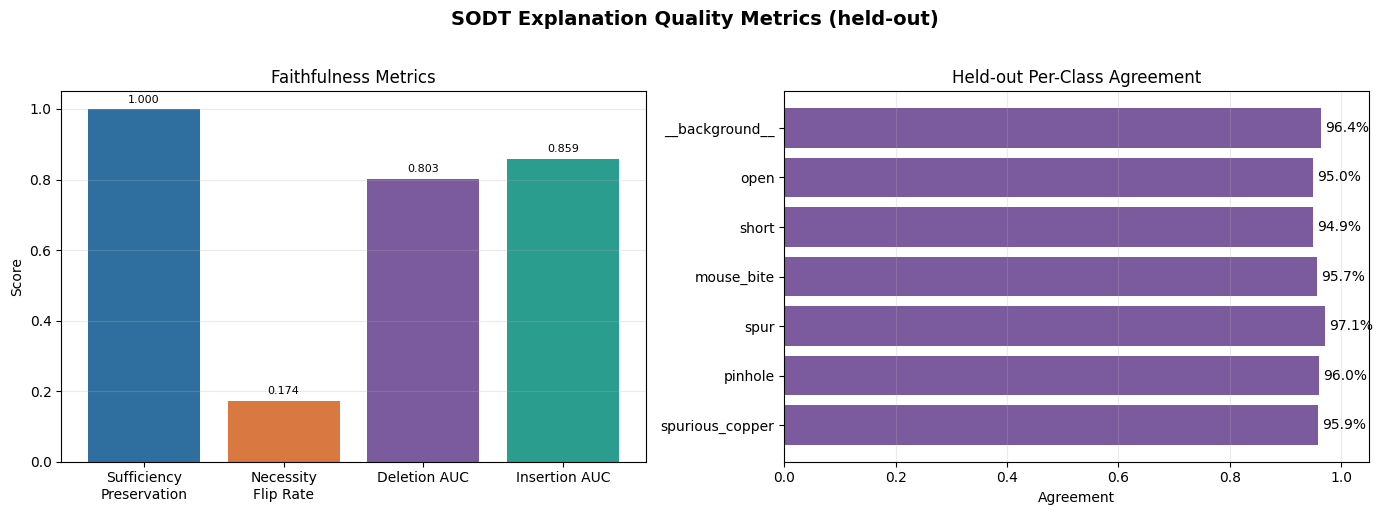

In [ ]:
train_metrics = summary["metrics"]
heldout_metrics = heldout_eval["metrics"]

feature_dim = int(np.prod(summary["feature_shape"]))
total_split_weights = train_metrics["num_internal_nodes"] * feature_dim
nonzero_weights = train_metrics["nonzero_weights"]
zero_weights = max(total_split_weights - nonzero_weights, 0)
weight_sparsity = zero_weights / max(total_split_weights, 1)

train_mimic = next(
    e["mimic_accuracy"] for e in reversed(summary["history"]) if "mimic_accuracy" in e
)
test_mimic = heldout_metrics["mimic_accuracy"]
tree = load_symbolic_tree(symbolic_checkpoint_path)
per_node_counts = tree.nonzero_weight_counts()
tree_class_names = summary["class_names"]
per_node_active = sorted(
    [(i, c) for i, c in enumerate(per_node_counts) if c > 0],
    key=lambda x: x[1],
    reverse=True,
)

class_agreement = heldout_metrics["per_class_agreement_vs_teacher"]
class_names_list = list(class_agreement.keys())
class_values = [class_agreement[name] for name in class_names_list]

# ── Figure 1: Detection Metrics ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    "SODT Student: Detection Metrics",
    fontsize=14,
    fontweight="bold",
    y=1.02,
)

ax = axes[0]
accuracy_labels = ["Train", "Held-out test"]
accuracy_values = [train_mimic, test_mimic]
accuracy_bars = ax.bar(accuracy_labels, accuracy_values, color=["#2F6F9F", "#D97941"])
ax.set_ylim(0, 1.05)
ax.set_ylabel("Mimic accuracy")
ax.set_title("Teacher-Student Agreement")
ax.bar_label(
    accuracy_bars, labels=[f"{value:.2%}" for value in accuracy_values], padding=3
)
ax.grid(axis="y", alpha=0.25)

ax = axes[1]
sparsity_labels = ["Nonzero", "Zero (pruned)"]
sparsity_values = [nonzero_weights, zero_weights]
sparsity_colors = ["#2F6F9F", "#E0E0E0"]
wedges, texts, autotexts = ax.pie(
    sparsity_values,
    labels=sparsity_labels,
    colors=sparsity_colors,
    autopct="%1.1f%%",
    startangle=90,
)
ax.set_title(f"Weight Sparsity ({weight_sparsity:.1%} sparse)")

fig.tight_layout()
plt.show()

# ── Figure 2: Explanation Quality ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    "SODT Explanation Quality Metrics (held-out)",
    fontsize=14,
    fontweight="bold",
    y=1.02,
)

ax = axes[0]
faith_labels = [
    "Sufficiency\nPreservation",
    "Necessity\nFlip Rate",
    "Deletion AUC",
    "Insertion AUC",
]
faith_values = [
    heldout_metrics.get("sufficiency_prediction_preservation", 0.0),
    heldout_metrics.get("necessity_prediction_flip_rate", 0.0),
    heldout_metrics.get("deletion_auc", 0.0),
    heldout_metrics.get("insertion_auc", 0.0),
]
faith_colors = ["#2F6F9F", "#D97941", "#7C5A9E", "#2a9d8f"]
faith_bars = ax.bar(faith_labels, faith_values, color=faith_colors)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Faithfulness Metrics")
ax.bar_label(faith_bars, fmt="%.3f", padding=3, fontsize=8)
ax.grid(axis="y", alpha=0.25)

ax = axes[1]
y_positions = np.arange(len(class_names_list))
class_bars = ax.barh(y_positions, class_values, color="#7C5A9E")
ax.set_yticks(y_positions)
ax.set_yticklabels(class_names_list)
ax.invert_yaxis()
ax.set_xlim(0, 1.05)
ax.set_xlabel("Agreement")
ax.set_title("Held-out Per-Class Agreement")
ax.bar_label(class_bars, labels=[f"{value:.1%}" for value in class_values], padding=3)
ax.grid(axis="x", alpha=0.25)

fig.tight_layout()
plt.show()

## Tree Structure: Unpruned vs Pruned

Side-by-side comparison of the full SODT tree (all 63 internal nodes + 64 leaves)
and the pruned tree (zero-weight subtrees collapsed, internal nodes show nonzero feature count).

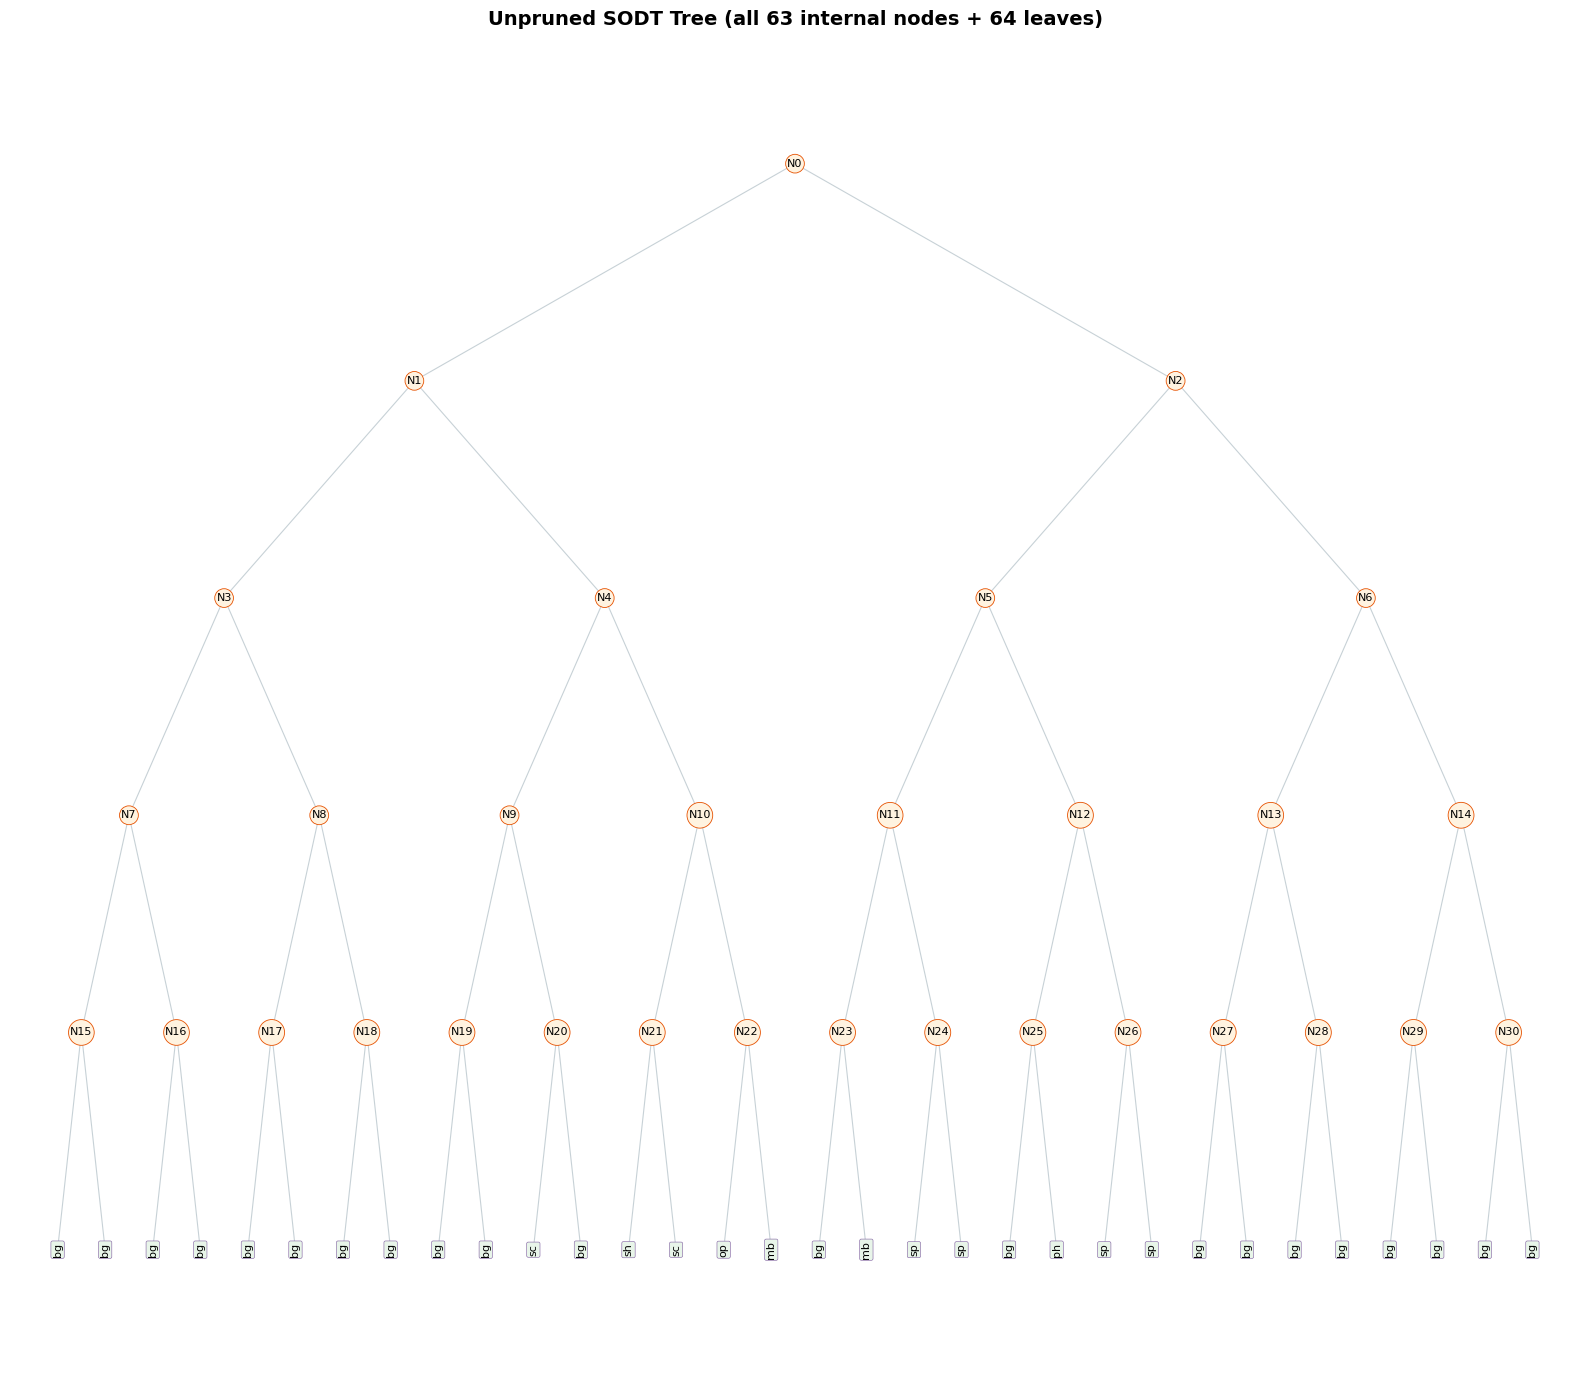

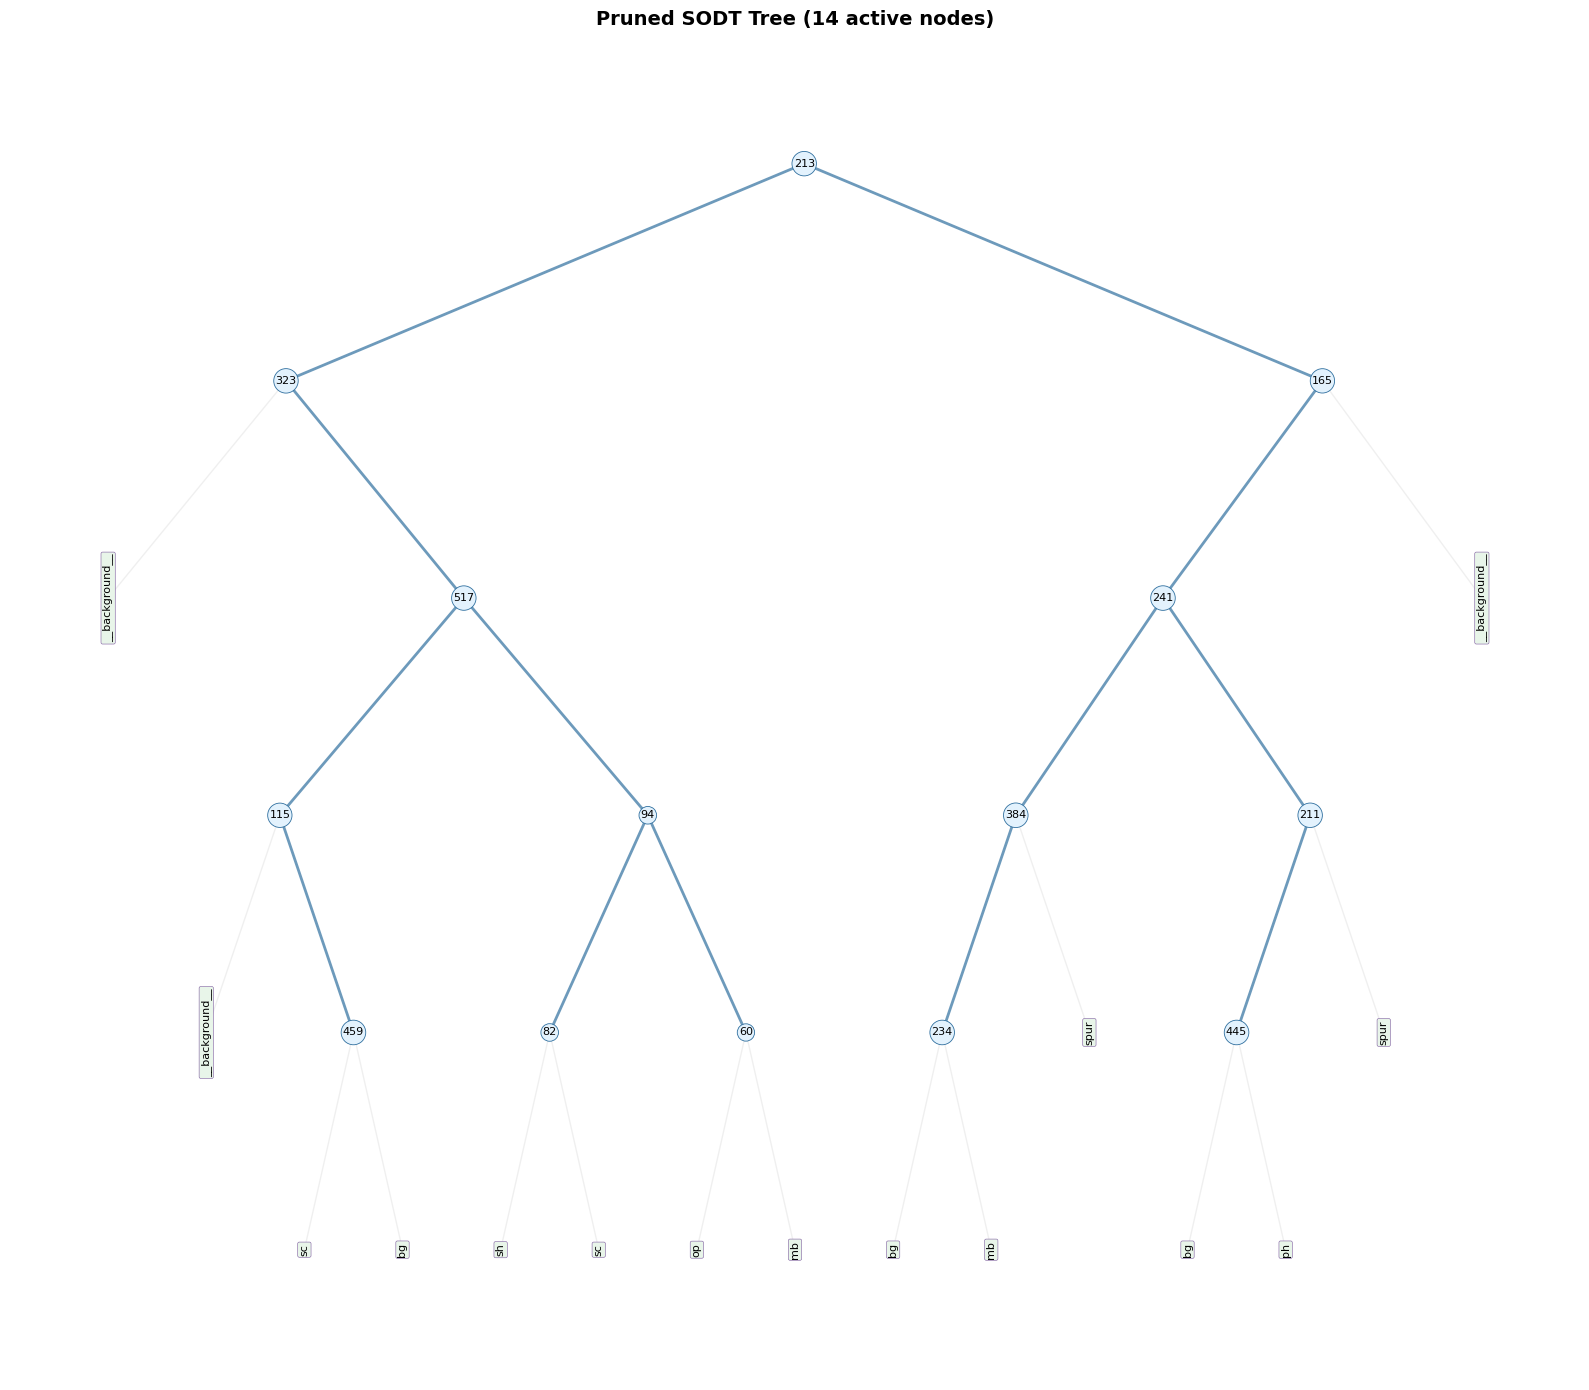

Unpruned tree: internal nodes show node ID (N0, N1, ...); leaves show abbreviated class name
Pruned tree:   internal nodes show nonzero feature count; pruned subtrees collapse to a single leaf
Abbreviations: bg=__background__, op=open, sh=short, mb=mouse_bite, sp=spur, ph=pinhole, sc=spurious_copper


In [ ]:
# ── Helper: render a tree on a given axis ──
_ABBREV = {
    "__background__": "bg",
    "open": "op",
    "short": "sh",
    "mouse_bite": "mb",
    "spur": "sp",
    "pinhole": "ph",
    "spurious_copper": "sc",
}


def _render_tree(
    ax,
    tree,
    tree_class_names,
    *,
    show_nonzero_counts,
    per_node_counts,
    title,
    leaf_spacing=40,
    show_leaf_ids=False,
):
    """Render SODT tree structure on a matplotlib axis.

    show_nonzero_counts=True  → internal nodes show nonzero feature count (pruned view)
    show_nonzero_counts=False → internal nodes show node ID (unpruned view)
    """
    num_internal = tree.num_internal_nodes

    # Identify structurally pruned nodes (all weights AND bias = 0)
    pruned = set()
    for idx in range(num_internal):
        if np.all(tree.node_weights[idx] == 0.0) and tree.node_bias[idx] == 0.0:
            pruned.add(idx)

    visible_nodes = set()
    visible_edges = []
    leaf_override = {}

    def _build(node, depth):
        visible_nodes.add(node)
        if node >= num_internal:
            return
        if show_nonzero_counts and node in pruned:
            # Collapse: find leftmost leaf class
            curr = node
            while curr < num_internal:
                curr = curr * 2 + 1
            leaf_off = curr - num_internal
            lidx = tree.leaf_labels[leaf_off]
            leaf_override[node] = tree_class_names[int(lidx)]
            return
        left = node * 2 + 1
        right = node * 2 + 2
        visible_edges.append((node, left))
        visible_edges.append((node, right))
        _build(left, depth + 1)
        _build(right, depth + 1)

    _build(0, 0)

    # Build parent-child map
    children_map = {}
    for p, c in visible_edges:
        children_map.setdefault(p, []).append(c)

    # Layout: leaves at bottom, internal nodes centered above children
    coords = {}
    leaf_x = [0]

    def _layout(node, depth):
        kids = sorted(children_map.get(node, []))
        if not kids:
            coords[node] = (leaf_x[0], -depth * 2.5)
            leaf_x[0] += leaf_spacing
        else:
            for c in kids:
                _layout(c, depth + 1)
            xs = [coords[c][0] for c in kids]
            coords[node] = (sum(xs) / len(xs), -depth * 2.5)

    _layout(0, 0)

    # Center the tree horizontally
    all_x = [v[0] for v in coords.values()]
    cx = (max(all_x) + min(all_x)) / 2
    for node in coords:
        coords[node] = (coords[node][0] - cx, coords[node][1])

    # Draw edges
    for p, c in visible_edges:
        if show_nonzero_counts:
            is_active = c < num_internal and c not in pruned
            color = "#2F6F9F" if is_active else "#cccccc"
            lw = 2 if is_active else 1
            alpha = 0.7 if is_active else 0.3
        else:
            color = "#90a4ae"
            lw = 0.8
            alpha = 0.5
        ax.plot(
            [coords[p][0], coords[c][0]],
            [coords[p][1], coords[c][1]],
            color=color,
            lw=lw,
            alpha=alpha,
        )

    # Draw nodes
    for node in sorted(visible_nodes):
        is_leaf = node >= num_internal or node in leaf_override
        x, y = coords[node]
        if is_leaf:
            if node in leaf_override:
                lbl = leaf_override[node]
            else:
                leaf_off = node - num_internal
                class_label = int(tree.leaf_labels[leaf_off])
                full_name = tree_class_names[class_label]
                lbl = _ABBREV.get(full_name, full_name[:4])
            fontsize = 8 if show_leaf_ids else 8
            ax.text(
                x,
                y,
                lbl,
                ha="center",
                va="center",
                fontsize=fontsize,
                rotation=90,
                rotation_mode="anchor",
                bbox=dict(
                    boxstyle="round,pad=0.15",
                    fc="#E8F5E9",
                    ec="#7C5A9E",
                    lw=0.4,
                ),
            )
        else:
            if show_nonzero_counts:
                cnt = per_node_counts[node]
                label = f"{cnt:,}"
                fc = "#E3F2FD"
                ec = "#2F6F9F"
            else:
                label = f"N{node}"
                fc = "#FFF3E0"
                ec = "#E65100"
            ax.text(
                x,
                y,
                label,
                ha="center",
                va="center",
                fontsize=8,
                bbox=dict(
                    boxstyle="circle,pad=0.15",
                    fc=fc,
                    ec=ec,
                    lw=0.6,
                ),
            )

    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.axis("off")

    # Set axis limits with padding
    if coords:
        min_x = min(v[0] for v in coords.values())
        max_x = max(v[0] for v in coords.values())
        ax.set_xlim(min_x - leaf_spacing, max_x + leaf_spacing)
        ax.set_ylim(-tree.max_depth * 2.5 - 1.5, 1.5)


# ── Unpruned tree (full width) ──
fig, ax = plt.subplots(figsize=(16, 14))
_render_tree(
    ax,
    tree,
    tree_class_names,
    show_nonzero_counts=False,
    per_node_counts=per_node_counts,
    title="Unpruned SODT Tree (all 63 internal nodes + 64 leaves)",
    leaf_spacing=20,
    show_leaf_ids=True,
)
plt.tight_layout()
plt.show()

# ── Pruned tree (full width) ──
fig, ax = plt.subplots(figsize=(16, 14))
_render_tree(
    ax,
    tree,
    tree_class_names,
    show_nonzero_counts=True,
    per_node_counts=per_node_counts,
    title="Pruned SODT Tree ({} active nodes)".format(len(per_node_active)),
    leaf_spacing=60,
)
plt.tight_layout()
plt.show()

# Legend
print(
    "Unpruned tree: internal nodes show node ID (N0, N1, ...); leaves show abbreviated class name"
)
print(
    "Pruned tree:   internal nodes show nonzero feature count; pruned subtrees collapse to a single leaf"
)
print(f"Abbreviations: {', '.join(f'{v}={k}' for k, v in _ABBREV.items())}")

## Training Diagnostics

Spatial grounding metrics and TAO training history.

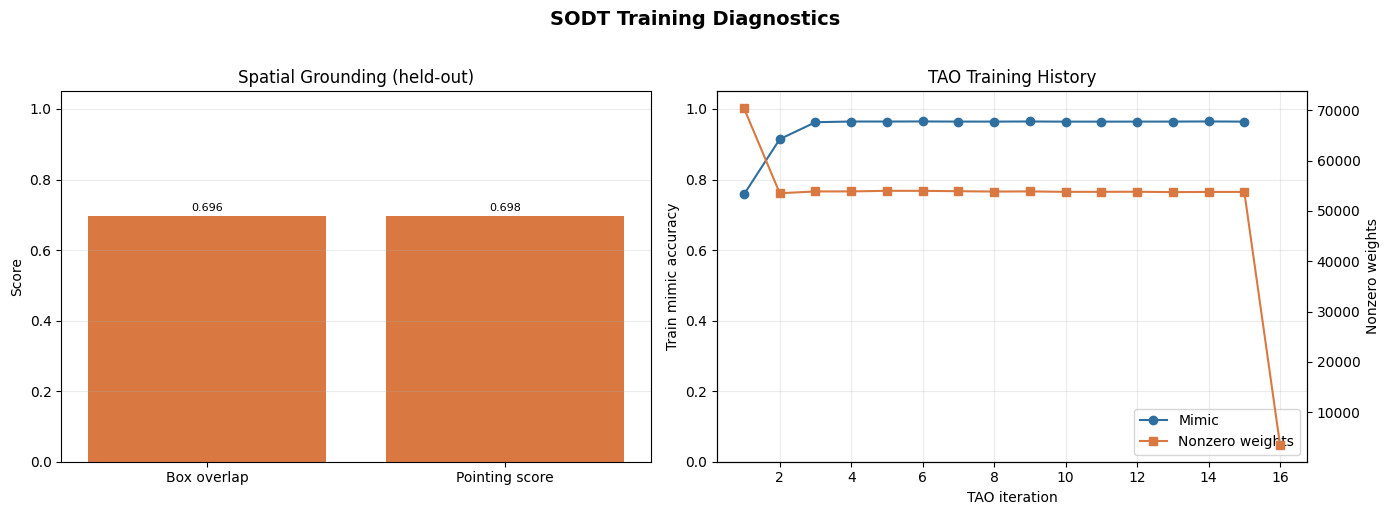

In [ ]:
history = pd.DataFrame(summary["history"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    "SODT Training Diagnostics",
    fontsize=14,
    fontweight="bold",
    y=1.02,
)

ax = axes[0]
spatial_metric_names = ["box_grounded_roi_overlap", "pointing_score"]
x = np.arange(len(spatial_metric_names))
test_spatial = [heldout_metrics[name] for name in spatial_metric_names]
bars = ax.bar(x, test_spatial, color="#D97941")
ax.bar_label(bars, fmt="%.3f", padding=2, fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(["Box overlap", "Pointing score"])
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Spatial Grounding (held-out)")
ax.grid(axis="y", alpha=0.25)

ax = axes[1]
if not history.empty:
    ax.plot(
        history["iteration"],
        history["mimic_accuracy"],
        color="#2F6F9F",
        marker="o",
        label="Mimic",
    )
    ax.set_ylim(0, 1.05)
    ax.set_xlabel("TAO iteration")
    ax.set_ylabel("Train mimic accuracy")
    ax.grid(alpha=0.25)
    ax_nonzero = ax.twinx()
    ax_nonzero.plot(
        history["iteration"],
        history["nonzero_weights"],
        color="#D97941",
        marker="s",
        label="Nonzero weights",
    )
    ax_nonzero.set_ylabel("Nonzero weights")
    lines, labels = ax.get_legend_handles_labels()
    extra_lines, extra_labels = ax_nonzero.get_legend_handles_labels()
    ax.legend(lines + extra_lines, labels + extra_labels, loc="lower right")
ax.set_title("TAO Training History")

fig.tight_layout()
plt.show()

In [ ]:
display(Markdown("### Single SODT Student Metrics"))
print(
    f"Train mimic accuracy: {train_mimic:.4f}\n"
    f"Held-out mimic accuracy: {test_mimic:.4f}\n"
    f"Nonzero weights: {nonzero_weights:,} / {total_split_weights:,} "
    f"({weight_sparsity:.1%} sparse)\n"
    f"Macro F1: {heldout_metrics.get('macro_f1_vs_teacher', 0.0):.4f}\n"
    f"Necessity flip rate: {heldout_metrics.get('necessity_prediction_flip_rate', 0.0):.4f}\n"
    f"Sufficiency preservation: {heldout_metrics.get('sufficiency_prediction_preservation', 0.0):.4f}\n"
    f"Deletion AUC: {heldout_metrics.get('deletion_auc', 0.0):.4f}\n"
    f"Insertion AUC: {heldout_metrics.get('insertion_auc', 0.0):.4f}\n"
    f"Per-node active count: {len(per_node_active)} / {len(per_node_counts)}"
)

### Single SODT Student Metrics

Train mimic accuracy: 0.9642
Held-out mimic accuracy: 0.9631
Nonzero weights: 3,543 / 97,216 (96.4% sparse)
Macro F1: 0.8879
Necessity flip rate: 0.1735
Sufficiency preservation: 1.0000
Deletion AUC: 0.8027
Insertion AUC: 0.8594
Per-node active count: 14 / 31
